# Runge–Kutta Stability — A Visual Introduction

This notebook is a quick, hands-on introduction to stability of Runge-Kutta methods. Let's avoid heavy theory and focus on one idea:

> A method is stable if it does not amplify errors.

---

## The Test Equation 

The stability of Runge–Kutta (RK) methods is traditionally analyzed using the **Dahlquist test equation**

$$
\frac{dy}{dt} = \lambda y, \quad y(0) = 1,
$$

Exact solution:
$$
y(t) = e^{\lambda t}
$$

If $\mathrm{Re}(\lambda) < 0$, the solution decays.

👉 A good numerical method should reproduce this behavior.

---

## Stability Function

All Runge–Kutta methods can be written as:
$$
y_{n+1} = R(z)\, y_n, \quad z = h\lambda
$$

- $R(z)$ → stability function  
- method is stable if:
$$
|R(z)| \le 1
$$

---

## Example: Explicit Euler

$$
R(z) = 1 + z
$$

👉 Stable only inside a small circle

---

## Let's Plot Stability Regions

We now visualize where:
$$
|R(z)| \le 1
$$


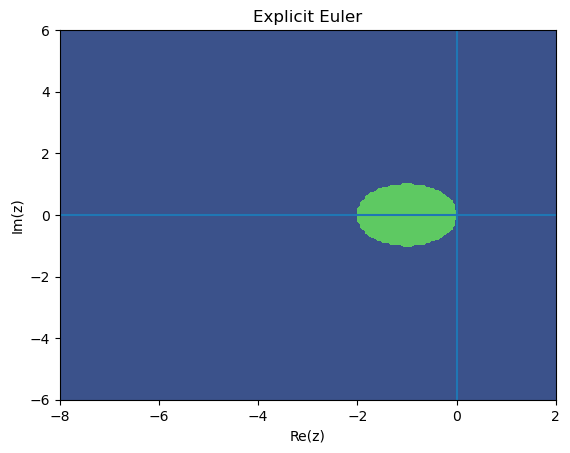

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.close('all')  # 

def plot_stability(R, title=""):
    x = np.linspace(-8, 2, 200)
    y = np.linspace(-6, 6, 200)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j*Y
    
    values = np.abs(R(Z))
    
    plt.figure()
    
    plt.contourf(X, Y, values <= 1)
    plt.axhline(0)
    plt.axvline(0)
    plt.title(title)
    plt.xlabel("Re(z)")
    plt.ylabel("Im(z)")
    plt.show()
plot_stability(lambda z: 1 + z, "Explicit Euler")

The pakage rk-stability-explorer offers a bunch of prescribed methods:

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import rk_stability_explorer as rk

rk.list_methods()

['BDF2',
 'ars22',
 'bogacki_shampine',
 'dopri5',
 'euler',
 'explicit_midpoint',
 'gauss_legendre_2',
 'heun',
 'implicit_midpoint',
 'kvarno',
 'optRK4',
 'optRK62',
 'ps36',
 'radauIIA',
 'rk3',
 'rk4',
 'skewedrk4',
 'spijker',
 'ssprk33',
 'williamson']

New method can be either prescribed as a .yaml file in src/methods or defined as the folllwoing:

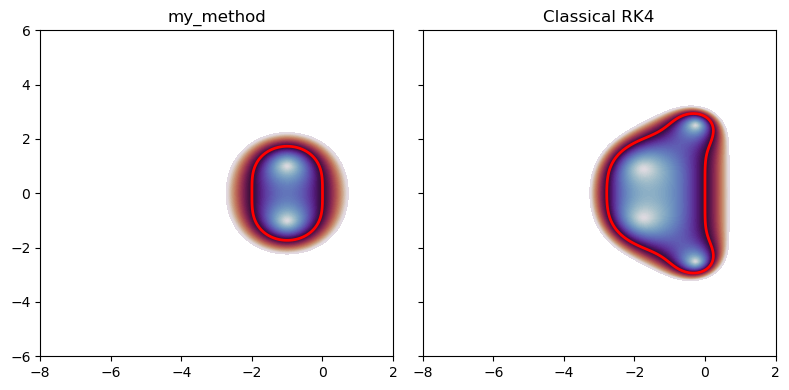

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import rk_stability_explorer as rk

plt.close('all')  # clean up figures

custom_method = {
    "A": [[0, 0],
          [1, 0]],
    "b": [0.5, 0.5],
    "name": "my_method"
}

methods = [
     custom_method,
     "rk4"
]

X, Y = rk.make_grid(n=200)
Z = X + 1j * Y

results = rk.compute_results(methods, X, Y, Z)
rk.rkplot_multiple(results, cols=2)
plt.show()

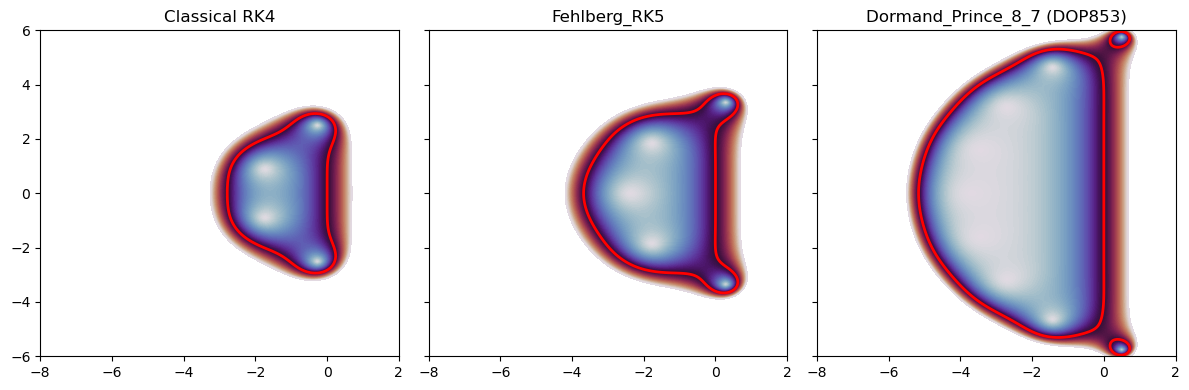

In [18]:
import matplotlib.pyplot as plt
plt.close('all')  # clean up figures
rkf5 = {
    "A": [
        [0, 0, 0, 0, 0, 0],
        [1/4, 0, 0, 0, 0, 0],
        [3/32, 9/32, 0, 0, 0, 0],
        [1932/2197, -7200/2197, 7296/2197, 0, 0, 0],
        [439/216, -8, 3680/513, -845/4104, 0, 0],
        [-8/27, 2, -3544/2565, 1859/4104, -11/40, 0]
    ],
    "b": [16/135, 0, 6656/12825, 28561/56430, -9/50, 2/55],
    "name": "Fehlberg_RK5"
}

dop853 = {
    "A": [
        [0,0,0,0,0,0,0,0,0,0,0,0,0],
        [1/18,0,0,0,0,0,0,0,0,0,0,0,0],
        [1/48,1/16,0,0,0,0,0,0,0,0,0,0,0],
        [1/32,0,3/32,0,0,0,0,0,0,0,0,0,0],
        [5/16,0,-75/64,75/64,0,0,0,0,0,0,0,0,0],
        [3/80,0,0,3/16,3/20,0,0,0,0,0,0,0,0],
        [29443841/614563906,0,0,77736538/692538347,
         -28693883/1125000000,23124283/1800000000,0,0,0,0,0,0,0],
        [16016141/946692911,0,0,61564180/158732637,
         22789713/633445777,545815736/2771057229,
         -180193667/1043307555,0,0,0,0,0,0],
        [39632708/573591083,0,0,-433636366/683701615,
         -421739975/2616292301,100302831/723423059,
         790204164/839813087,800635310/3783071287,0,0,0,0,0],
        [246121993/1340847787,0,0,-37695042795/15268766246,
         -309121744/1061227803,-12992083/490766935,
         6005943493/2108947869,393006217/1396673457,
         123872331/1001029789,0,0,0,0],
        [-1028468189/846180014,0,0,8478235783/508512852,
         1311729495/1432422823,-10304129995/1701304382,
         -48777925059/3047939560,15336726248/1032824649,
         -45442868181/3398467696,3065993473/597172653,0,0,0],
        [185892177/718116043,0,0,-3185094517/667107341,
         -477755414/1098053517,-703635378/230739211,
         5731566787/1027545527,5232866602/850066563,
         -4093664535/808688257,3962137247/1805957418,
         65686358/487910083,0,0],
        [403863854/491063109,0,0,-5068492393/434740067,
         -411421997/543043805,652783627/914296604,
         11173962825/925320556, -13158990841/6184727034,
         3936647629/1978049680, -160528059/685178525,
         248638103/1413531060,0,0]
    ],
    "b": [
        14005451/335480064,
        0,
        0,
        0,
        0,
        -59238493/1068277825,
        181606767/758867731,
        561292985/797845732,
        -1041891430/1371343529,
        760417239/1151165299,
        118820643/751138087,
        -528747749/2220607170,
        1/4
    ],
    "name": "Dormand_Prince_8_7 (DOP853)"
}

methods = [
    "rk4",
    rkf5, dop853
]

X, Y = rk.make_grid(n=200)
Z = X + 1j * Y

results = rk.compute_results(methods, X, Y, Z)
rk.rkplot_multiple(results, cols=3)
plt.show()

In [ ]:
#fig.savefig("Rk4-8.png",  dpi=200, bbox_inches = 'tight', pad_inches = 0)